### Дизайн A/B [кнопка «В корзину» в листинге товаров]

**Гипотеза:** если добавить кнопку «В корзину» прямо на карточку товара в каталоге / рекомендациях, то путь до корзины станет короче, `View → Cart CR` вырастет и через рост покупок увеличится **ARPU**.

Метрики:

- **Target:** `ARPU = Revenue / Users`
- **Прокси:** `View → Cart CR`
- **Защитная:** `Cart → Purchase CR`

In [1]:
import getpass
import numpy as np
import pandas as pd
import scipy.stats as sps
import matplotlib.pyplot as plt
import clickhouse_connect

from collections import namedtuple

In [ ]:
client = clickhouse_connect.get_client(
    host="of3x1087uw.europe-west4.gcp.clickhouse.cloud",
    port=8443,
    username="default",
    password="",
    secure=True,
)

print("Connected")

Connected


In [3]:
WEEK_OPTIONS = [1, 2, 3, 4, 5, 6, 8]

ALPHA = 0.05
POWER = 0.80
BETA = 1 - POWER

N_AA_SPLITS = 30
RANDOM_SEED = 11

In [ ]:
query = f"""
SELECT
    toStartOfWeek(event_time) AS week_dt,
    clean_user_id AS user_id,
    sumIf(price, event_type = 'purchase') AS revenue,
    max(event_type = 'view') AS has_view,
    max(event_type = 'cart') AS has_cart,
    max(event_type = 'purchase') AS has_purchase
FROM mart.events_clean_v3
WHERE clean_user_id IS NOT NULL
GROUP BY
    week_dt,
    user_id
ORDER BY
    week_dt,
    user_id
"""

user_week = client.query_df(query)
user_week["week_dt"] = pd.to_datetime(user_week["week_dt"])
user_week["revenue"] = user_week["revenue"].astype(float)

for col in ["has_view", "has_cart", "has_purchase"]:
    user_week[col] = user_week[col].astype(int)

Rows: 43046897
Users: 15632734
Weeks: 31
Period: 2019-09-29 00:00:00 — 2020-04-26 00:00:00


,week_dt,user_id,revenue,has_view,has_cart,has_purchase
0,2019-09-29,183503497,NaN,1,0,0
1,2019-09-29,184265397,NaN,1,0,0
2,2019-09-29,208669541,NaN,1,0,0
3,2019-09-29,239475080,NaN,1,0,0
4,2019-09-29,240522111,NaN,1,0,0


In [ ]:
ExperimentComparisonResults = namedtuple(
    "ExperimentComparisonResults",
    ["pvalue", "effect", "MDE", "ci_length", "left_bound", "right_bound"]
)

# относительный т-тест, дисперсия расписана через дельта-метод 
def relative_ttest(control, test, two_sided_alpha=0.05, beta_for_mde=0.2):
    mean_control = np.mean(control)
    var_mean_control = np.var(control) / len(control)
    difference_mean = np.mean(test) - mean_control
    difference_mean_var = np.var(test) / len(test) + var_mean_control
    covariance = -var_mean_control
    relative_effect = difference_mean / mean_control

    relative_var = (
        difference_mean_var / (mean_control ** 2)
        + var_mean_control * ((difference_mean ** 2) / (mean_control ** 4))
        - 2 * (difference_mean / (mean_control ** 3)) * covariance
    )

    relative_distribution = sps.norm(loc=relative_effect,scale=np.sqrt(relative_var))
    h0_distr = sps.norm(loc=0, scale=np.sqrt(relative_var))
    left_bound, right_bound = relative_distribution.ppf([two_sided_alpha / 2, 1 - two_sided_alpha / 2])
    ci_length = right_bound - left_bound
    pvalue = 2 * min(relative_distribution.cdf(0), relative_distribution.sf(0))

    mde = h0_distr.ppf(1 - two_sided_alpha / 2) + h0_distr.ppf(1 - beta_for_mde)

    return ExperimentComparisonResults(pvalue, relative_effect, mde, ci_length, left_bound, right_bound,)


def make_grouped_user_dataset(df, group_cols):
    return df.groupby("user_id", as_index=False)[group_cols].sum().fillna(0)


def make_user_metrics_dataset(df):
    # Одна строка = один пользователь за всё выбранное окно эксперимента
    return (
        df.groupby("user_id", as_index=False)
        .agg(
            revenue=("revenue", "sum"),
            has_view=("has_view", "max"),
            has_cart=("has_cart", "max"),
            has_purchase=("has_purchase", "max"),
        )
        .fillna(0)
    )


In [6]:
weeks = sorted(user_week["week_dt"].unique())

full_weeks = weeks[:-1]

print("Полных недель:", len(full_weeks))
print("Последняя используемая неделя:", full_weeks[-1])

if max(WEEK_OPTIONS) > len(full_weeks):
    raise ValueError(
        f"В WEEK_OPTIONS запрошено до {max(WEEK_OPTIONS)} недель, "
        f"а доступно только {len(full_weeks)} полных недель"
    )

Полных недель: 30
Последняя используемая неделя: 2020-04-19 00:00:00


In [12]:
np.random.seed(RANDOM_SEED)

weeks_length_array = np.array(WEEK_OPTIONS)

arpu_mde_array = []
view_to_cart_mde_array = []
cart_to_purchase_mde_array = []

results = []

for weeks_length in weeks_length_array:
    
    # Берём последние N полных недель
    selected_weeks = full_weeks[-weeks_length:]
    curr_df = user_week[user_week["week_dt"].isin(selected_weeks)].copy()
    
    # Агрегируем метрики до уровня пользователя
    curr_df = make_user_metrics_dataset(curr_df)

    # Случайно делим пользователей на test / control
    curr_df["group"] = np.random.choice(["test", "control"], size=len(curr_df))

    test_df = curr_df[curr_df["group"] == "test"]
    control_df = curr_df[curr_df["group"] == "control"]

    # Target: ARPU
    arpu_mde = relative_ttest(control_df["revenue"].values, test_df["revenue"].values, two_sided_alpha=ALPHA, beta_for_mde=BETA).MDE * 100
    arpu_mde_array.append(arpu_mde)

    # Proxy: View -> Cart CR
    test_view = test_df[test_df["has_view"] == 1]["has_cart"].values
    control_view = control_df[control_df["has_view"] == 1]["has_cart"].values

    view_to_cart_mde = relative_ttest(control_view, test_view, two_sided_alpha=ALPHA, beta_for_mde=BETA).MDE * 100
    view_to_cart_mde_array.append(view_to_cart_mde)

    # Guardrail: Cart -> Purchase CR
    test_cart = test_df[test_df["has_cart"] == 1]["has_purchase"].values
    control_cart = control_df[control_df["has_cart"] == 1]["has_purchase"].values

    cart_to_purchase_mde = relative_ttest(control_cart, test_cart, two_sided_alpha=ALPHA, beta_for_mde=BETA).MDE * 100
    cart_to_purchase_mde_array.append(cart_to_purchase_mde)

    # Базовые значения метрик
    arpu = curr_df["revenue"].mean()
    view_to_cart = curr_df[curr_df["has_view"] == 1]["has_cart"].mean()
    cart_to_purchase = curr_df[curr_df["has_cart"] == 1]["has_purchase"].mean()

    results.append({
        "weeks": weeks_length,
        "users": len(curr_df),
        "ARPU": arpu,
        "ARPU_MDE_%": arpu_mde,
        "View_to_Cart_CR": view_to_cart,
        "View_to_Cart_MDE_%": view_to_cart_mde,
        "Cart_to_Purchase_CR": cart_to_purchase,
        "Cart_to_Purchase_MDE_%": cart_to_purchase_mde
    })


mde_df = pd.DataFrame(results)

mde_df.round({
    "ARPU": 2,
    "ARPU_MDE_%": 2,
    "View_to_Cart_CR": 4,
    "View_to_Cart_MDE_%": 2,
    "Cart_to_Purchase_CR": 4,
    "Cart_to_Purchase_MDE_%": 2
})

,weeks,users,ARPU,ARPU_MDE_%,View_to_Cart_CR,View_to_Cart_MDE_%,Cart_to_Purchase_CR,Cart_to_Purchase_MDE_%
0,1,1749484,26.14,3.68,0.1902,0.88,0.3760,1.25
1,2,2866077,39.18,2.80,0.2017,0.66,0.4509,0.81
2,3,3545853,46.20,2.56,0.2078,0.58,0.4711,0.69
3,4,4043658,53.79,2.34,0.2142,0.53,0.4883,0.62
4,5,4484366,60.97,2.26,0.2190,0.50,0.5008,0.56
5,6,4917036,68.58,2.27,0.2236,0.47,0.5123,0.52
6,8,6572725,78.76,2.03,0.2197,0.41,0.5306,0.44


### График MDE от длительности теста

MDE для всех метрик эксперимента:
- ARPU
- View → Cart CR
- Cart → Purchase CR

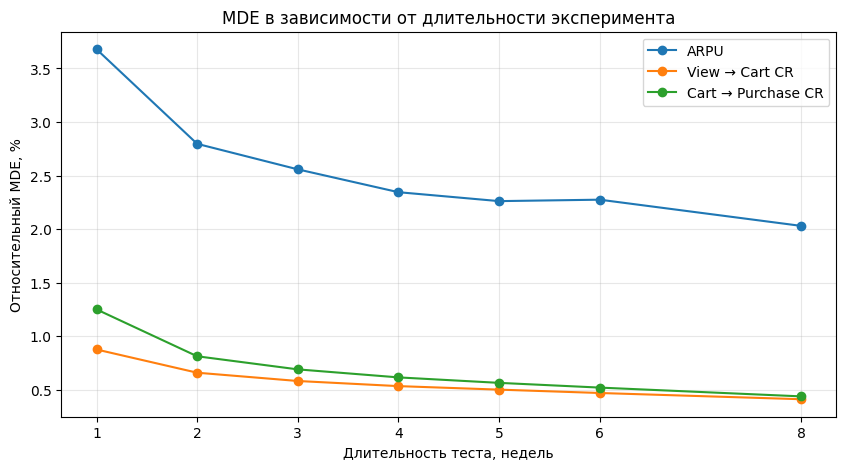

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(mde_df["weeks"], mde_df["ARPU_MDE_%"], marker="o", label="ARPU")
plt.plot(mde_df["weeks"], mde_df["View_to_Cart_MDE_%"], marker="o", label="View → Cart CR",)
plt.plot(mde_df["weeks"], mde_df["Cart_to_Purchase_MDE_%"], marker="o", label="Cart → Purchase CR",)
plt.title("MDE")
plt.xlabel("Длительность теста, недель")
plt.ylabel("Относительный MDE, %")
plt.xticks(mde_df["weeks"])
plt.grid(alpha=0.3)
plt.legend()
plt.show()